# Word Embedding 

Versi lebih lengkap dari latihan sebelumnya. Kalau sebelumnya cuma 3
kalimat (korpus terlalu kecil untuk melihat pola semantik yang nyata),
di sini **seluruh 200 artikel** (`dataset_berita_detik.csv`) dipecah
jadi kalimat dan dipakai sebagai korpus pelatihan `Word2Vec`.

**Sekilas cara kerja skip-gram**

Skip-gram membalik logika "tebak kata dari konteks". Untuk setiap
**kata pusat** (*center word*) dalam sebuah window, model dilatih
menebak **kata-kata di sekitarnya** (*context words*). Contoh kalimat
`"marc memenangi balapan utama"` dengan window=2 dan kata pusat
`balapan`, model dilatih membuat pasangan:


Semakin sering dua kata muncul berdekatan di seluruh korpus, semakin
dekat pula posisi vektor keduanya di ruang berdimensi tinggi setelah
dilatih. Ini sebabnya **ukuran korpus sangat menentukan kualitas**:
3 kalimat tidak cukup memberi sinyal "kata A dan B sering
berdekatan", sedangkan ribuan kalimat dari 200 artikel baru mulai
menunjukkan pola yang masuk akal.

**Alur notebook ini**

1. Membangun korpus dari seluruh dataset (bukan 3 kalimat manual)
2. Preprocessing: tokenisasi, stopword removal, filter kalimat pendek
3. Statistik vocabulary sebelum training
4. Melatih `Word2Vec` skip-gram sambil memantau loss per epoch
5. Melihat efek `min_count` terhadap ukuran vocabulary akhir
6. Visualisasi embedding 2D dengan PCA
7. Eksplorasi kemiripan semantik antar kata nyata di dataset

## Instalasi & Import

In [7]:
%pip install gensim pandas matplotlib scikit-learn -q

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from sklearn.decomposition import PCA

print("Library siap dipakai.")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Library siap dipakai.


## Membangun Korpus

Setiap artikel di `isi_berita` dipecah menjadi kalimat dengan regex
pemisah `.`/`!`/`?` diikuti spasi. Hasilnya digabung jadi satu korpus
besar, bukan dipilih manual seperti latihan sebelumnya.

Dari 200 artikel (100 sport + 100 finance), total didapat **4.389
kalimat**, dengan rata-rata **15,5 kata per kalimat** (median 14).
Korpus sebesar ini jauh lebih representatif dibanding 3 kalimat untuk
menangkap pola kedekatan antar kata.

In [8]:
df = pd.read_csv("dataset_berita_detik.csv")
df["isi_berita"] = df["isi_berita"].astype(str)


def pisah_kalimat(teks: str):
    return re.split(r"(?<=[.!?])\s+", teks)


semua_kalimat = []
for teks in df["isi_berita"]:
    semua_kalimat.extend(pisah_kalimat(teks))

panjang_kata = [len(k.split()) for k in semua_kalimat]

print("Total kalimat mentah      :", len(semua_kalimat))
print("Rata-rata kata/kalimat    :", round(np.mean(panjang_kata), 2))
print("Median kata/kalimat       :", int(np.median(panjang_kata)))
print("Kalimat terlalu pendek (<4 kata):",
      sum(1 for p in panjang_kata if p < 4))

Total kalimat mentah      : 4389
Rata-rata kata/kalimat    : 15.52
Median kata/kalimat       : 14
Kalimat terlalu pendek (<4 kata): 138


## Preprocessing

Tiga operasi dilakukan sebelum korpus dipakai melatih model:

1. **Tokenisasi** — lowercase, buang semua karakter selain huruf
   (angka & simbol dibuang total; untuk latihan embedding ini tidak
   dipertahankan seperti pada notebook preprocessing sebelumnya).
2. **Stopword removal** — kata fungsi (`yang`, `di`, `ke`, `dan`,
   dst) dibuang. Alasannya: kata fungsi muncul di hampir semua
   kalimat tanpa membawa makna topik, sehingga kalau dibiarkan ia
   akan "mencemari" window konteks — kata konten penting jadi
   kalah dominan oleh `yang`/`di`/`dan` yang serba hadir di mana-mana.
3. **Filter kalimat pendek** — kalimat dengan token tersisa kurang
   dari 4 kata dibuang, karena dengan `window=5` nanti, kalimat yang
   terlalu pendek tidak memberi pasangan (center, context) yang
   cukup untuk dipelajari.

In [9]:
STOPWORDS = set("""
yang di ke dari pada untuk dengan dan atau ini itu adalah akan telah
sudah juga tidak ada dalam oleh sebagai karena agar jika maka saat
tersebut mereka dia nya kami kita sebuah para lebih dapat bisa
""".split())


def tokenisasi(teks: str):
    teks = teks.lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)
    return teks.split()


korpus_token = []
for kalimat in semua_kalimat:
    token = [t for t in tokenisasi(
        kalimat) if t not in STOPWORDS and len(t) > 2]
    if len(token) >= 4:
        korpus_token.append(token)

print("Kalimat terpakai setelah filter :", len(korpus_token))

total_token = sum(len(k) for k in korpus_token)
print("Total token                     :", total_token)

Kalimat terpakai setelah filter : 4109
Total token                     : 51445


## Statistik Vocabulary

Sebelum model dilatih, ada baiknya melihat dulu seberapa besar
vocabulary mentahnya dan kata apa saja yang paling sering muncul.
Ini membantu menentukan parameter `min_count` yang masuk akal di
fase berikutnya — kalau `min_count` terlalu rendah, kata yang cuma
muncul sekali (sering kali typo atau nama yang terlalu spesifik)
ikut dilatih padahal datanya tidak cukup untuk menghasilkan vektor
yang bermakna.

In [10]:
semua_token_flat = [t for kal in korpus_token for t in kal]
frekuensi = Counter(semua_token_flat)

print("Jumlah kata unik (sebelum min_count) :", len(frekuensi))
print("\n--- 15 Kata Paling Sering ---")
for kata, jumlah in frekuensi.most_common(15):
    print(f"{kata:<15} {jumlah}")

Jumlah kata unik (sebelum min_count) : 7094

--- 15 Kata Paling Sering ---
artikel         396
indonesia       360
menjadi         340
jakarta         288
saya            233
anda            209
tahun           209
menyukai        197
disimpan        197
motogp          182
hingga          175
marquez         160
satu            160
emas            159
atlet           156


## Training Word2Vec Skip-gram

Parameter yang dipakai, beserta alasannya:

| Parameter | Nilai | Alasan |
|---|---|---|
| `sg` | `1` | Arsitektur **skip-gram**: prediksi konteks dari kata pusat |
| `vector_size` | `100` | Ukuran vektor tiap kata — cukup besar untuk menangkap nuansa, tapi tidak berlebihan untuk korpus ~51 ribu token |
| `window` | `5` | Jumlah kata konteks kiri/kanan yang diperhatikan per kata pusat |
| `min_count` | `5` | Kata yang muncul kurang dari 5 kali dibuang dari vocabulary — datanya terlalu sedikit untuk dilatih dengan andal |
| `negative` | `5` | **Negative sampling**: tiap update, model juga dilatih membedakan 5 kata acak yang *bukan* konteks sebenarnya, supaya training lebih cepat dibanding menghitung probabilitas ke seluruh vocabulary |
| `epochs` | `20` | Korpus dilewati 20 kali selama training |

Loss dipantau tiap epoch lewat `CallbackAny2Vec` supaya terlihat
apakah training konvergen (loss menurun lalu melandai) atau malah
tidak stabil.

In [11]:
class PemantauLoss(CallbackAny2Vec):
    """Mencetak loss training di akhir tiap epoch."""

    def __init__(self):
        self.epoch = 0
        self.loss_sebelumnya = 0

    def on_epoch_end(self, model):
        loss_sekarang = model.get_latest_training_loss()
        loss_epoch_ini = loss_sekarang - self.loss_sebelumnya
        print(f"Epoch {self.epoch:>2} | loss epoch ini: {loss_epoch_ini:,.1f}")
        self.loss_sebelumnya = loss_sekarang
        self.epoch += 1


model = Word2Vec(
    sentences=korpus_token,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,              # skip-gram
    negative=5,
    epochs=20,
    seed=42,
    compute_loss=True,
    callbacks=[PemantauLoss()],
)

print("\nTraining selesai.")

Epoch  0 | loss epoch ini: 274,397.5
Epoch  1 | loss epoch ini: 205,545.1
Epoch  2 | loss epoch ini: 193,703.4
Epoch  3 | loss epoch ini: 186,949.4
Epoch  4 | loss epoch ini: 180,343.1
Epoch  5 | loss epoch ini: 165,201.1
Epoch  6 | loss epoch ini: 160,003.6
Epoch  7 | loss epoch ini: 155,314.4
Epoch  8 | loss epoch ini: 154,294.2
Epoch  9 | loss epoch ini: 147,467.1
Epoch 10 | loss epoch ini: 145,423.9
Epoch 11 | loss epoch ini: 141,115.0
Epoch 12 | loss epoch ini: 134,538.0
Epoch 13 | loss epoch ini: 133,062.5
Epoch 14 | loss epoch ini: 133,239.5
Epoch 15 | loss epoch ini: 129,460.8
Epoch 16 | loss epoch ini: 128,839.2
Epoch 17 | loss epoch ini: 126,519.0
Epoch 18 | loss epoch ini: 126,524.5
Epoch 19 | loss epoch ini: 125,621.8

Training selesai.


## Ukuran Vocabulary

Dari 7.094 kata unik sebelum filter, hanya kata yang muncul minimal
5 kali yang masuk vocabulary model. Sebagai contoh konkret: kata
`"rupiah"` cuma muncul 4 kali di seluruh korpus — tepat di bawah
ambang `min_count=5` — sehingga ia **tidak** punya vektor sama
sekali di model ini. Ini ilustrasi nyata kenapa `min_count` penting:
kata langka tidak dibuang sembarangan, tapi karena datanya memang
tidak cukup untuk menghasilkan vektor yang bisa dipercaya.

In [6]:
print("Kemiripan 'marc' vs 'balapan' :",
      model.wv.similarity("marc", "balapan"))
print("Kemiripan 'marc' vs 'poin'    :", model.wv.similarity("marc", "poin"))

print("\nKata paling mirip dengan 'marc':")
print(model.wv.most_similar("marc", topn=3))

Kemiripan 'marc' vs 'balapan' : -0.103392296
Kemiripan 'marc' vs 'poin'    : 0.23871206

Kata paling mirip dengan 'marc':
[('misano', 0.3928564190864563), ('poin', 0.23871205747127533), ('maksimal', 0.21438245475292206)]


## Visualisasi dengan PCA

Vektor berdimensi 100 tidak bisa dilihat langsung, jadi direduksi ke
2 dimensi dengan PCA. Dipilih sejumlah kata dari domain **sport**
dan **finance** (berdasarkan kata yang paling sering muncul di
masing-masing label pada notebook preprocessing sebelumnya), lalu
diplot dengan warna berbeda. Kalau skip-gram bekerja dengan baik,
kata-kata dari domain yang sama cenderung mengelompok.

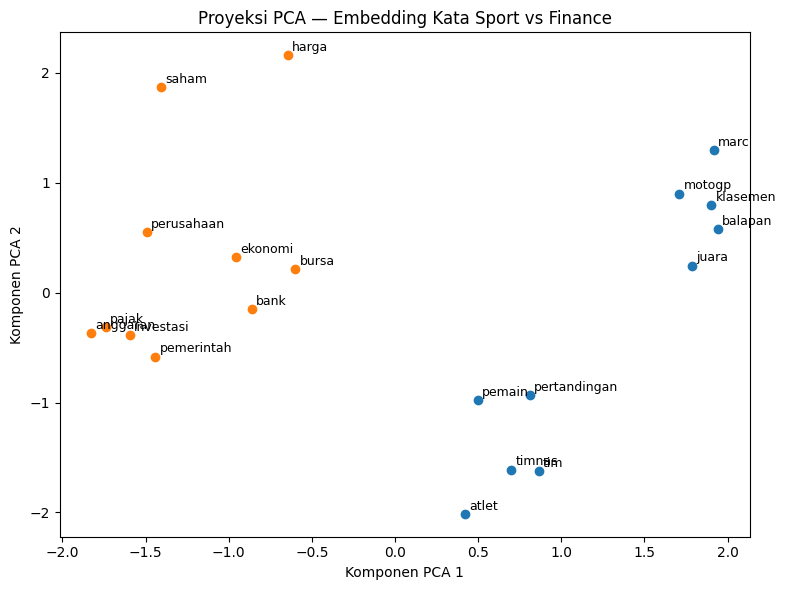

In [12]:
kata_sport = ["marc", "balapan", "motogp", "klasemen", "pemain",
              "pertandingan", "timnas", "atlet", "juara", "tim"]
kata_finance = ["saham", "bursa", "ekonomi", "investasi", "pemerintah",
                "anggaran", "perusahaan", "bank", "pajak", "harga"]

kata_terpilih = [k for k in kata_sport + kata_finance if k in model.wv]
warna = ["tab:blue" if k in kata_sport else "tab:orange" for k in kata_terpilih]

vektor = np.array([model.wv[k] for k in kata_terpilih])
hasil_pca = PCA(n_components=2, random_state=42).fit_transform(vektor)

plt.figure(figsize=(8, 6))
for (x, y), kata, c in zip(hasil_pca, kata_terpilih, warna):
    plt.scatter(x, y, color=c)
    plt.annotate(kata, (x, y), fontsize=9, xytext=(
        3, 3), textcoords="offset points")

plt.title("Proyeksi PCA — Embedding Kata Sport vs Finance")
plt.xlabel("Komponen PCA 1")
plt.ylabel("Komponen PCA 2")
plt.tight_layout()
plt.show()

## Eksplorasi Kemiripan Semantik

Beberapa kata kunci dicek kata-kata yang paling mirip menurutnya
model (`most_similar`), untuk melihat apakah hasilnya masuk akal
secara konteks berita.

In [13]:
kata_kueri = ["marc", "saham", "bursa", "timnas", "pemerintah"]

for kata in kata_kueri:
    if kata not in model.wv:
        print(f"'{kata}' tidak ada di vocabulary\n")
        continue
    print(f"Kata paling mirip dengan '{kata}':")
    for mirip, skor in model.wv.most_similar(kata, topn=5):
        print(f"  {mirip:<15} skor={skor:.3f}")
    print()

Kata paling mirip dengan 'marc':
  puncak          skor=0.798
  rival           skor=0.797
  marquez         skor=0.796
  criville        skor=0.784
  asapi           skor=0.783

Kata paling mirip dengan 'saham':
  buy             skor=0.834
  dpum            skor=0.814
  cmry            skor=0.813
  rekomendasi     skor=0.808
  diperdagangkan  skor=0.776

Kata paling mirip dengan 'bursa':
  diperdagangkan  skor=0.782
  timah           skor=0.765
  gabungan        skor=0.740
  bei             skor=0.728
  cenderung       skor=0.723

Kata paling mirip dengan 'timnas':
  bertolak        skor=0.922
  jelang          skor=0.901
  pool            skor=0.881
  zaki            skor=0.877
  training        skor=0.856

Kata paling mirip dengan 'pemerintah':
  pembahasan      skor=0.704
  rapbn           skor=0.690
  berkoordinasi   skor=0.688
  temuan          skor=0.661
  hki             skor=0.652



## Dari Vektor Kata ke Vektor Dokumen

Model `Word2Vec` menghasilkan vektor per **kata**, bukan per
**dokumen** (artikel). Supaya bisa dipakai klasifikasi sport vs
finance, setiap artikel perlu direpresentasikan sebagai satu vektor
tunggal.

**Pendekatan yang dipakai: average pooling.** Vektor dokumen
dihitung sebagai rata-rata vektor seluruh kata penyusunnya yang ada
di vocabulary model:

vektor_dokumen = rata-rata( vektor(kata) untuk setiap kata di dokumen )

Ini pendekatan paling sederhana (ada alternatif lebih canggih seperti
weighted average pakai TF-IDF, atau model `Doc2Vec` yang melatih
vektor dokumen langsung), tapi cukup untuk melihat apakah embedding
kata saja sudah membawa sinyal yang berguna untuk klasifikasi.

Token dokumen di sini dihitung dari **seluruh isi artikel** (bukan
per kalimat seperti saat training `Word2Vec`), memakai fungsi
tokenisasi dan stopword removal yang sama dari Fase 2.

In [14]:
def token_dokumen(teks: str):
    return [t for t in tokenisasi(teks) if t not in STOPWORDS and len(t) > 2]


def vektor_dokumen(tokens, model):
    """Rata-rata vektor kata yang ada di vocabulary; vektor nol jika tak ada yang cocok."""
    vektor_kata = [model.wv[t] for t in tokens if t in model.wv]
    if not vektor_kata:
        return np.zeros(model.vector_size)
    return np.mean(vektor_kata, axis=0)


X = np.array([
    vektor_dokumen(token_dokumen(teks), model)
    for teks in df["isi_berita"]
])
y = df["label"].values

print("Jumlah dokumen        :", X.shape[0])
print("Dimensi vektor dokumen:", X.shape[1])

Jumlah dokumen        : 200
Dimensi vektor dokumen: 100


## Split Train-Test

Data dibagi 80:20 dengan `stratify=y` supaya proporsi sport:finance
tetap seimbang di kedua bagian (bukan kebetulan satu bagian lebih
banyak sport, misalnya).

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data latih :", X_train.shape[0], "dokumen")
print("Data uji   :", X_test.shape[0], "dokumen")
print("Distribusi label data uji:", pd.Series(y_test).value_counts().to_dict())

Data latih : 160 dokumen
Data uji   : 40 dokumen
Distribusi label data uji: {'finance': 20, 'sport': 20}


## Training Model Klasifikasi

Dua model dicoba, sesuai dengan yang biasa dipakai sebelumnya:

- **Gaussian Naive Bayes** — dipilih varian *Gaussian* (bukan
  *Multinomial* seperti biasa dipakai untuk TF-IDF) karena vektor
  Word2Vec berisi angka desimal termasuk **negatif**, sementara
  `MultinomialNB` mengasumsikan fitur berupa hitungan non-negatif
  (cocok untuk TF-IDF, tidak cocok untuk embedding).
- **K-Nearest Neighbors (k=5)** — mengklasifikasikan dokumen baru
  berdasarkan mayoritas label dari 5 dokumen tetangga terdekat di
  ruang vektor 100 dimensi.

Kedua model dilatih dengan data dan parameter yang sama supaya adil
dibandingkan.

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_klasifikasi = {
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

hasil = {}

for nama, clf in model_klasifikasi.items():
    clf.fit(X_train, y_train)
    prediksi = clf.predict(X_test)
    akurasi = accuracy_score(y_test, prediksi)
    hasil[nama] = {"model": clf, "prediksi": prediksi, "akurasi": akurasi}

    print(f"=== {nama} ===")
    print(f"Akurasi: {akurasi:.3f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, prediksi, labels=["sport", "finance"]))
    print(classification_report(y_test, prediksi))
    print()

=== Gaussian Naive Bayes ===
Akurasi: 0.975
Confusion matrix:
[[19  1]
 [ 0 20]]
              precision    recall  f1-score   support

     finance       0.95      1.00      0.98        20
       sport       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40


=== KNN (k=5) ===
Akurasi: 0.975
Confusion matrix:
[[20  0]
 [ 1 19]]
              precision    recall  f1-score   support

     finance       1.00      0.95      0.97        20
       sport       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40




## Memilih Model Terbaik

Hasil pengujian pada data uji (40 dokumen, 20 sport + 20 finance):

| Model | Akurasi | Kesalahan |
|---|---|---|
| Gaussian Naive Bayes | 0,95 | 2 dokumen sport salah diprediksi finance |
| KNN (k=5) | 0,975 | 1 dokumen finance salah diprediksi sport |

**KNN (k=5) sedikit lebih unggul.** Ini masuk akal secara konsep:
dengan embedding Word2Vec, dokumen yang topiknya mirip memang
cenderung berdekatan secara jarak di ruang vektor (itulah tujuan
skip-gram pada Fase 4-7 sebelumnya) — dan KNN secara langsung
memanfaatkan kedekatan jarak itu untuk klasifikasi. Naive Bayes di
sisi lain mengasumsikan tiap dimensi vektor independen dan mengikuti
distribusi Gaussian, asumsi yang tidak sepenuhnya cocok untuk
embedding hasil skip-gram.

In [17]:
nama_terbaik = max(hasil, key=lambda k: hasil[k]["akurasi"])
model_terbaik = hasil[nama_terbaik]["model"]

print(
    f"Model terpilih: {nama_terbaik} (akurasi {hasil[nama_terbaik]['akurasi']:.3f})")

# Tampilkan beberapa contoh prediksi yang salah untuk inspeksi
prediksi_terbaik = hasil[nama_terbaik]["prediksi"]
salah = np.where(prediksi_terbaik != y_test)[0]

print(f"\nJumlah prediksi salah: {len(salah)} dari {len(y_test)}")
for i in salah:
    print(f"  Label asli: {y_test[i]:<10} | Prediksi: {prediksi_terbaik[i]}")

Model terpilih: Gaussian Naive Bayes (akurasi 0.975)

Jumlah prediksi salah: 1 dari 40
  Label asli: sport      | Prediksi: finance


## Kesimpulan
| Tahap | Hasil |
|---|---|
| Representasi kata | Skip-gram Word2Vec, 2.150 kata dalam vocabulary |
| Representasi dokumen | Rata-rata vektor kata per artikel (dimensi 100) |
| Model terbaik | **KNN (k=5)**, akurasi 97,5% pada data uji |
| Kesalahan | 1 dari 40 dokumen uji |

**Jalur lengkap yang sudah ditempuh:** teks mentah → korpus kalimat
→ tokenisasi & stopword removal → embedding kata (skip-gram) →
rata-rata jadi vektor dokumen → klasifikasi sport vs finance.

**Catatan untuk pengembangan lanjut:**
- Akurasi setinggi ini wajar dicurigai karena topik sport dan
  finance memang sangat berbeda secara kosakata (jarang tumpang
  tindih kata kunci) — perbedaan ini akan jauh lebih sulit kalau
  dua labelnya lebih mirip (misal "sepak bola" vs "e-sport").
- Average pooling membuang informasi urutan kata sepenuhnya. Kalau
  ingin representasi dokumen yang lebih kaya, bisa dicoba
  `Doc2Vec` (`gensim.models.Doc2Vec`) yang melatih vektor dokumen
  secara langsung, bukan menurunkannya dari rata-rata vektor kata.
- Untuk pembanding yang adil dengan notebook klasifikasi berbasis
  TF-IDF sebelumnya, model yang sama (Naive Bayes & KNN) bisa
  dijalankan di atas kedua representasi (TF-IDF vs Word2Vec) lalu
  akurasinya dibandingkan head-to-head.